In [2]:
import pandas as pd

### 1. Cargar datos

In [2]:
data = pd.read_csv("datasets/carros/car details v3.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
# Tamaño de los datos
data.shape

(8128, 13)

### 2. Describir los datos

In [4]:
data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [5]:
print(data.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')


In [6]:
# Valores con respecto a la categoría fuel o combustible
data["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [7]:
data["owner"].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

### 3. Visualizar datos

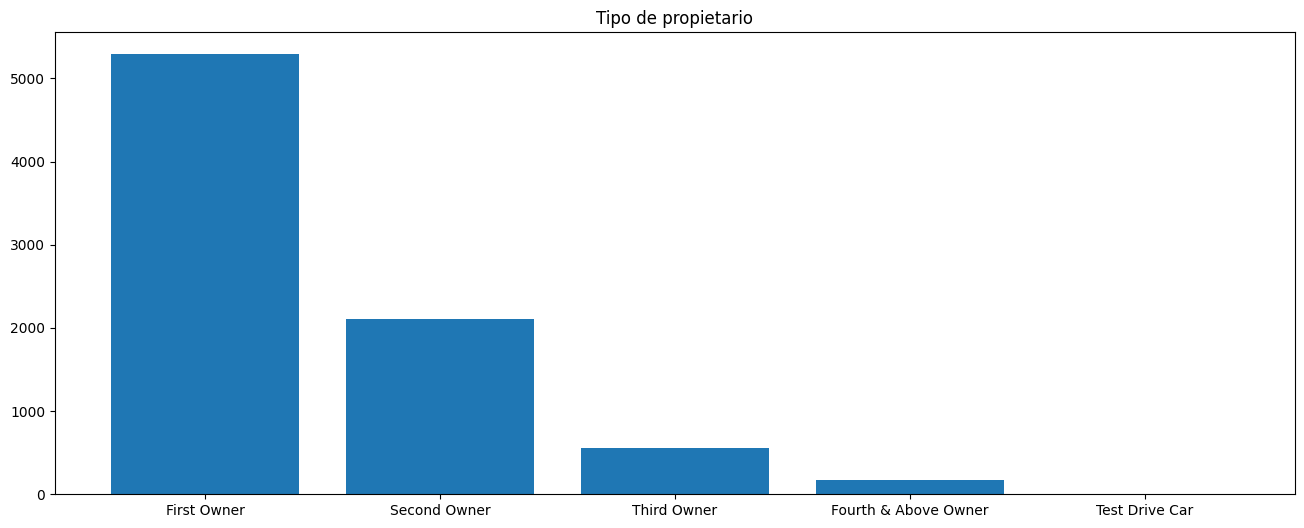

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
plt.bar(data["owner"].unique(), data["owner"].value_counts())
plt.title("Tipo de propietario")
plt.show()

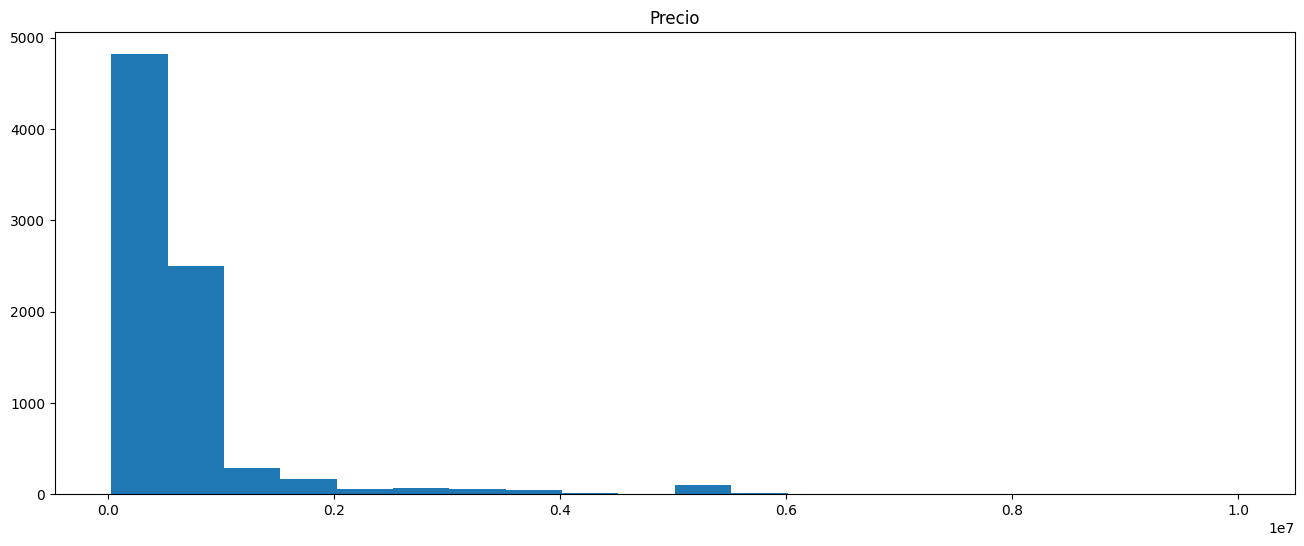

In [9]:
plt.figure(figsize=(16,6))
plt.hist(data["selling_price"], bins=20)
plt.title("Precio")
plt.show()

In [10]:
data.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

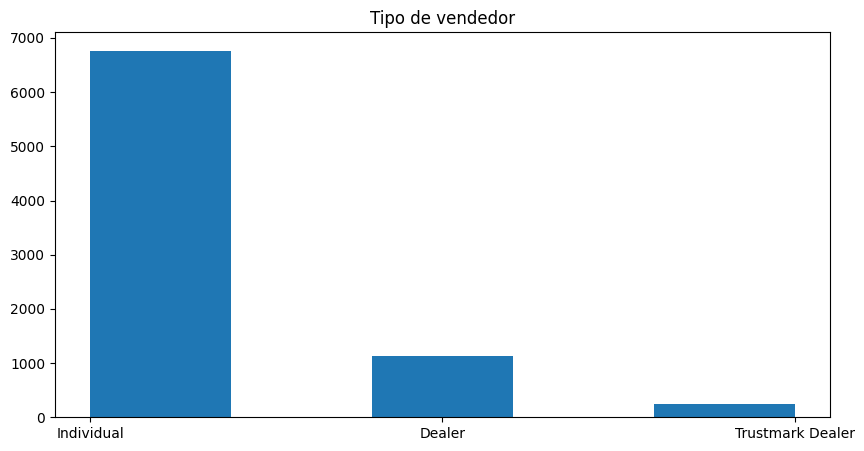

In [11]:
plt.figure(figsize=(10,5))
plt.hist(data["seller_type"],bins=5)
plt.title("Tipo de vendedor")
plt.show()

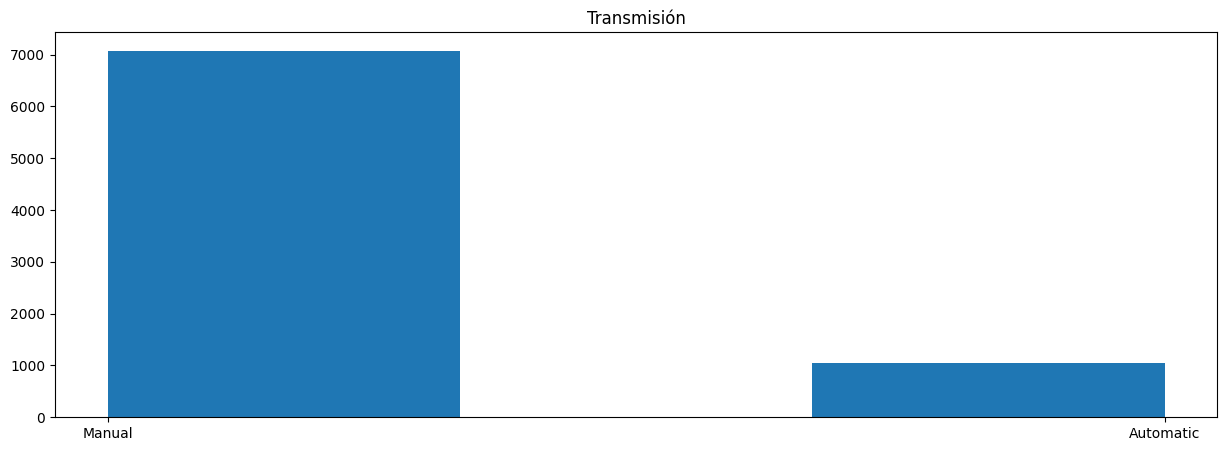

In [12]:
plt.figure(figsize=(15,5))
plt.hist(data["transmission"], bins=3)
plt.title("Transmisión")
plt.show()

In [13]:
data["engine"].value_counts()

engine
1248 CC    1017
1197 CC     832
998 CC      453
796 CC      444
2179 CC     389
           ... 
2650 CC       1
2446 CC       1
3498 CC       1
2776 CC       1
1950 CC       1
Name: count, Length: 121, dtype: int64

In [15]:
# Procesado de los datos antes de graficar
data["max_power"] = data["max_power"].str.replace(" bhp", "", regex=False).str.strip()
data["engine"] = data["engine"].str.replace(" CC", "", regex=False).str.strip()

In [19]:
# Convertir 'max_power' a numérico, reemplazando errores con NaN
data["max_power"] = pd.to_numeric(data["max_power"], errors='coerce')

# Convertir 'engine' a numérico, reemplazando errores con NaN
data["engine"] = pd.to_numeric(data["engine"], errors='coerce')

In [22]:
data.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine           float64
max_power        float64
torque            object
seats            float64
dtype: object

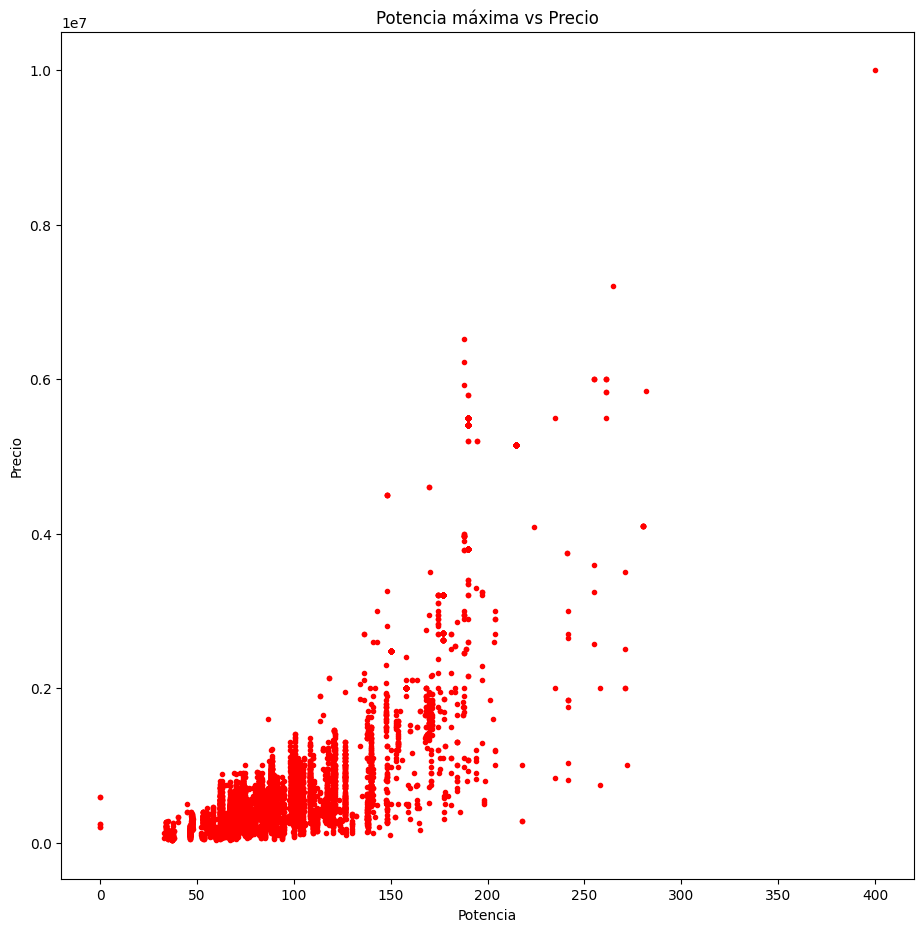

In [26]:
plt.figure(figsize=(11,11))
plt.plot(data["max_power"], data["selling_price"], ".", color="red")
plt.title("Potencia máxima vs Precio")
plt.xlabel("Potencia")
plt.ylabel("Precio")
plt.show()

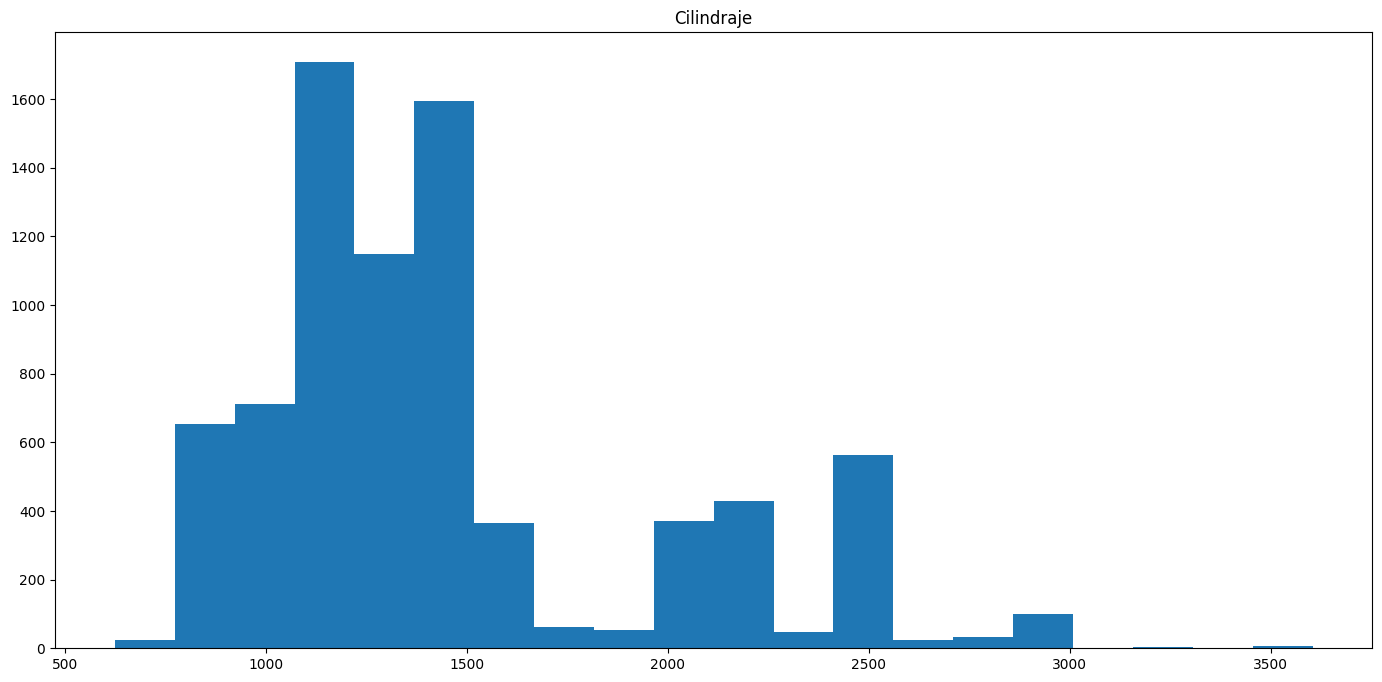

In [21]:
plt.figure(figsize=(17,8))
plt.hist(data["engine"], bins=20)
plt.title("Cilindraje")
plt.show()